# Chess Puzzle Dataset Generation and Analysis

## Data Extraction

In [199]:
import pandas as pd

# Set the maximum width of the text printout to effectively infinity
pd.set_option('display.width', 1000)

# Ensure Pandas displays all columns horizontally instead of dropping them
pd.set_option('display.max_columns', None)

# Prevent long individual column strings from getting truncated
pd.set_option('display.max_colwidth', None)

In [200]:
# Load the primary dataset of chess puzzles from the CSV file
puzzles_df = pd.read_csv(r'data/lichess_db_puzzle.csv', nrows=1000) # Load only the first 1000 rows for analysis

# Rename columns for clarity
puzzles_df.rename(columns={'PuzzleId': 'puzzle_id', 'FEN': 'setup_fen', 'Moves': 'moves', 'Rating': 'elo_rating', 'RatingDeviation': 'rating_deviation', 'Popularity': 'popularity', 'NbPlays': 'num_of_plays', 'Themes': 'themes', 'GameUrl': 'game_url', 'OpeningTags': 'opening_tags'}, inplace=True)

print(puzzles_df.head())
print(puzzles_df.columns)

  puzzle_id                                                             setup_fen                          moves  elo_rating  rating_deviation  popularity  num_of_plays                                 themes                               game_url                                         opening_tags
0     00008                  r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - - 0 24  f2g3 e6e7 b2b1 b3c1 b1c1 h6c1        1928                76          95          8070  crushing hangingPiece long middlegame  https://lichess.org/787zsVup/black#48                                                  NaN
1     0000D                  5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - - 2 27            d3d6 f8d8 d6d8 f6d8        1471                74          96         32392                advantage endgame short        https://lichess.org/F8M8OS71#53                                                  NaN
2     0008Q                          8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64            e7f7 f5

### Extracting Metadata

In [201]:
from collections import Counter
import matplotlib.pyplot as plt

In [202]:
# Split the Move sequence into individual moves and display the first few rows
puzzles_df['moves_list'] = puzzles_df['moves'].str.split()
print(puzzles_df[['moves', 'moves_list']].head())

                           moves                            moves_list
0  f2g3 e6e7 b2b1 b3c1 b1c1 h6c1  [f2g3, e6e7, b2b1, b3c1, b1c1, h6c1]
1            d3d6 f8d8 d6d8 f6d8              [d3d6, f8d8, d6d8, f6d8]
2            e7f7 f5e5 e2f1 e5e6              [e7f7, f5e5, e2f1, e5e6]
3            b6c5 e2g4 h3g4 d1g4              [b6c5, e2g4, h3g4, d1g4]
4  g6f5 d5c5 c2e4 h5g5 g7h8 g5f6  [g6f5, d5c5, c2e4, h5g5, g7h8, g5f6]


20 Most Common Moves: [('g1h1', 29), ('d1d8', 25), ('e8e1', 24), ('g8f8', 23), ('g8h8', 21), ('f7f6', 19), ('e1e8', 19), ('g8h7', 18), ('g1f1', 18), ('c1b1', 18), ('g1h2', 17), ('f7g6', 17), ('f7f8', 16), ('g5f4', 16), ('d8d1', 16), ('g8g7', 15), ('e1f1', 14), ('f8f7', 14), ('h7h6', 13), ('g7f6', 13)]


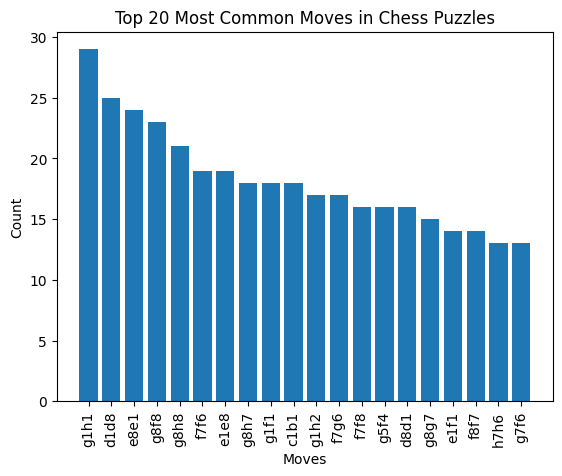

In [203]:
# Extract the moves and show a distribution of the number of moves in the puzzles
all_moves = [move for moves in puzzles_df['moves_list'] for move in moves]
move_counts = Counter(all_moves)
print(f"20 Most Common Moves: {move_counts.most_common(20)}")

# Bar graph for distribution of the top 20 most common themes
import matplotlib.pyplot as plt
top_moves = move_counts.most_common(20)
moves, counts = zip(*top_moves)
plt.bar(moves, counts)
plt.xticks(rotation=90)
plt.title('Top 20 Most Common Moves in Chess Puzzles')
plt.xlabel('Moves')
plt.ylabel('Count')
plt.show()


In [204]:
# Split the Themes sequence into individual themes and display the first few rows
puzzles_df['themes_list'] = puzzles_df['themes'].str.split()
print(puzzles_df[['themes', 'themes_list']].head())

                                  themes                                 themes_list
0  crushing hangingPiece long middlegame  [crushing, hangingPiece, long, middlegame]
1                advantage endgame short                 [advantage, endgame, short]
2    advantage endgame rookEndgame short    [advantage, endgame, rookEndgame, short]
3             advantage middlegame short              [advantage, middlegame, short]
4                  crushing endgame long                   [crushing, endgame, long]


20 Most Common Themes: [('short', 519), ('endgame', 496), ('middlegame', 453), ('crushing', 391), ('mate', 314), ('advantage', 284), ('long', 251), ('master', 157), ('mateIn1', 156), ('oneMove', 156), ('fork', 141), ('mateIn2', 130), ('kingsideAttack', 73), ('sacrifice', 68), ('veryLong', 67), ('advancedPawn', 61), ('pin', 54), ('rookEndgame', 53), ('opening', 51), ('defensiveMove', 51)]


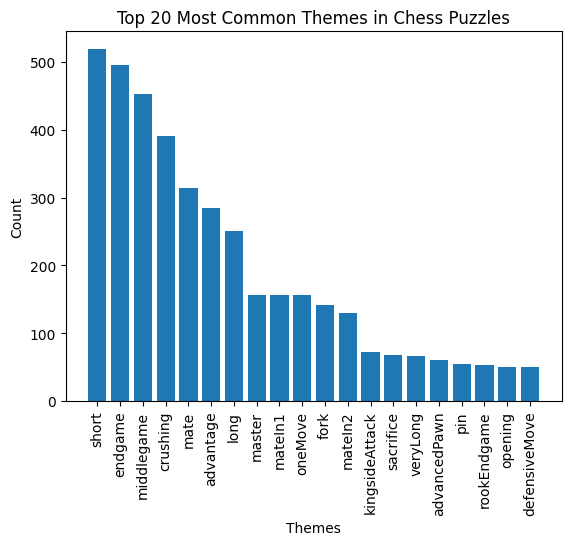

In [205]:
# Extract the themes and show a distribution of the most common themes in the dataset
all_themes = [theme for themes in puzzles_df['themes_list'] for theme in themes]
theme_counts = Counter(all_themes)
print(f"20 Most Common Themes: {theme_counts.most_common(20)}")

# Bar graph for distribution of the top 20 most common themes
top_themes = theme_counts.most_common(20)
themes, counts = zip(*top_themes)
plt.bar(themes, counts)
plt.xticks(rotation=90)
plt.title('Top 20 Most Common Themes in Chess Puzzles')
plt.xlabel('Themes')
plt.ylabel('Count')
plt.show()


In [206]:
# Split the Opening Tags into individual tags and display the first few rows
puzzles_df['openings_list'] = puzzles_df['opening_tags'].str.split()

# Replace NaN values with empty lists to avoid issues when splitting
puzzles_df['openings_list'] = puzzles_df['openings_list'].apply(lambda x: x if isinstance(x, list) else [])

print(puzzles_df[['opening_tags', 'openings_list']].head())

                                          opening_tags                                           openings_list
0                                                  NaN                                                      []
1                                                  NaN                                                      []
2                                                  NaN                                                      []
3  Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Variation  [Kings_Pawn_Game, Kings_Pawn_Game_Leonardis_Variation]
4                                                  NaN                                                      []


20 Most Common Openings: [('Sicilian_Defense', 29), ('French_Defense', 18), ('Scandinavian_Defense', 17), ('Queens_Pawn_Game', 17), ('Caro-Kann_Defense', 13), ('Italian_Game', 13), ('Kings_Pawn_Game', 8), ('Queens_Gambit_Declined', 8), ('Scandinavian_Defense_Modern_Variation', 7), ('Scotch_Game', 7), ('Kings_Gambit_Accepted', 7), ('Scandinavian_Defense_Main_Line', 7), ('English_Opening', 6), ('Ruy_Lopez', 5), ('Pirc_Defense', 5), ('Sicilian_Defense_Old_Sicilian', 5), ('Slav_Defense', 4), ('Queens_Pawn_Game_Accelerated_London_System', 4), ('Queens_Pawn_Game_Other_variations', 4), ('Italian_Game_Giuoco_Pianissimo', 4)]


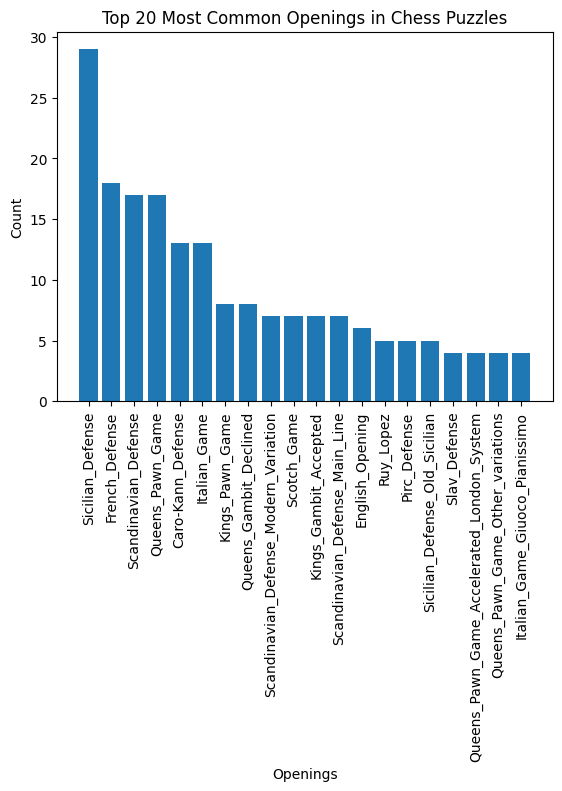

In [207]:
# Extract the openings and show a distribution of the most common openings in the dataset
all_openings = [opening for openings in puzzles_df['openings_list'] for opening in openings]
opening_counts = Counter(all_openings)
print(f"20 Most Common Openings: {opening_counts.most_common(20)}")

# Bar graph for distribution of the top 20 most common openings
top_openings = opening_counts.most_common(20)
openings, counts = zip(*top_openings)
plt.bar(openings, counts)
plt.xticks(rotation=90)
plt.title('Top 20 Most Common Openings in Chess Puzzles')
plt.xlabel('Openings')
plt.ylabel('Count')
plt.show()

In [208]:
# FEN Extractions

# Create a column for each piece type and its positions
def extract_pieces(fen):
    board = fen.split()[0]
    pieces = {p: [] for p in 'PNBRQKpnbrqk'}
    rows = board.split('/')
    for r, row in enumerate(rows):
        c = 0
        for char in row:
            if char.isdigit():
                c += int(char)
            else:
                pieces[char].append((r, c))
                c += 1
    return pieces

# Create a column for the side to move
def extract_side_to_move(fen):
    return fen.split()[1]

# Create a column for castling rights
def extract_castling_rights(fen):
    return fen.split()[2]

# Create a column for en passant target square
def extract_en_passant(fen):
    return fen.split()[3]

# Create a column for halfmove clock
def extract_halfmove_clock(fen):
    return fen.split()[4]

# Create a column for fullmove number
def extract_fullmove_number(fen):
    return fen.split()[5]

# Load the extracted features into the new dataframe
puzzles_df['pieces_list'] = puzzles_df['setup_fen'].apply(extract_pieces)
puzzles_df['side_to_move'] = puzzles_df['setup_fen'].apply(extract_side_to_move)
puzzles_df['castling_rights'] = puzzles_df['setup_fen'].apply(extract_castling_rights)
puzzles_df['en_passant'] = puzzles_df['setup_fen'].apply(extract_en_passant)
puzzles_df['halfmove_clock'] = puzzles_df['setup_fen'].apply(extract_halfmove_clock)
puzzles_df['fullmove_number'] = puzzles_df['setup_fen'].apply(extract_fullmove_number)

print(puzzles_df[['setup_fen', 'pieces_list', 'side_to_move', 'castling_rights', 'en_passant', 'halfmove_clock', 'fullmove_number']].head())



                                                              setup_fen                                                                                                                                                                                                                                                                                                                           pieces_list side_to_move castling_rights en_passant halfmove_clock fullmove_number
0                  r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - - 0 24                                                                              {'P': [(5, 3), (6, 0), (6, 2), (6, 6), (6, 7)], 'N': [(5, 1)], 'B': [], 'R': [(2, 4), (5, 6)], 'Q': [(2, 7)], 'K': [(7, 7)], 'p': [(1, 0), (1, 1), (1, 7), (2, 5), (3, 3)], 'n': [], 'b': [(6, 5)], 'r': [(0, 0), (1, 4)], 'q': [(6, 1)], 'k': [(0, 7)]}            b               -          -              0              24
1                  5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w

## Position Labeling

### Positional Sentiment Labeling
Each record will have 2 sentiment scores, one for black and one for white. Puzzle records follow a strict processing flow that makes sentiment easy to calculate based on the side to move. The first side to move from the setup fen is always about to play a "losing" move, making the position after the second "solution" move, always a winning for the player and losing positions for the opponent.
1. The records initial FEN is a setup position that will have an unknown sentiment for both sides. They start with the opponent to move.
2. After the first move is applied, it is now considered the players turn. In this position the opponent has made a losing move and their sentiment now drops to -1 while the players rises to +1.
3. After the second move is applied (the puzzles first "solution" move), the player has now made a winning move and their sentiment should be incremented by 1 while the opponents sentiment should be decremented by 1.
4. If additional moves exist, the process continues with the players winning moves incrementing their sentiment and the opponents compromised positions decrementing their sentiment until the final move is reached.
5. Once the final position is reached the position is now at max sentiment for the player (+num_of_moves) and min sentiment for the opponent (-num_of_moves).

Move 0 (initial FEN): white_sentiment = 0, black_sentiment = 0  
Move 1 (after first move): if side_to_move is white, white_sentiment = -1, black_sentiment = +1, else if side_to_move is black, white_sentiment = +1, black_sentiment = -1  
Move 2 (after second move): if side_to_move is white, white_sentiment = +1, black_sentiment = -1, else if side_to_move is black, white_sentiment = -1, black_sentiment = +1  

Example: Start both sides with 0 sentiment Initial FEN states black to move, after the first move is applied, black has made a losing move so the position is a -1 sentiment for black and a +1 sentiment for white, after the second move is applied, white has made a winning move so the position is now a +2 sentiment for white and a -2 sentiment for black, if a third move exists and is made by black, it is now a -3 sentiment for black and a +3 sentiment for white, if a fourth move exists and is made by white, and so on.  
 

In [209]:
import pandas as pd
import chess

def flatten_puzzle_dataset(df_puzzles):
    """
    Flattens a puzzle dataframe containing 'FEN' and 'moves_list' into a 
    state-transition dataset tracking board sentiment changes.
    
    Locks the identity of the loser to whoever makes the very first move 
    in the puzzle list, scaling the advantage deterministically.
    """
    flattened_records = []
    
    for idx, row in df_puzzles.iterrows():
        puzzle_id = row['puzzle_id']
        start_fen = row['setup_fen']
        moves = row['moves_list']
        
        if not moves:
            continue
            
        # Initialize python-chess board with the pre-puzzle FEN
        board = chess.Board(start_fen)
        
        # Determine the locked identities for the entire puzzle sequence
        # Whoever is moving first in the sequence is making the blunder.
        blunderer_color = "white" if board.turn == chess.WHITE else "black"
        winner_color = "black" if blunderer_color == "white" else "white"
        
        # Step 0: Record the initial "null sentiment" baseline
        current_fen = start_fen
        
        # Scale magnitude progressively as the tactical advantage solidifies
        sentiment_magnitude = 1
        
        for step_idx, move_str in enumerate(moves, start=1):
            try:
                move = chess.Move.from_uci(move_str)
            except ValueError:
                break
                
            if move in board.legal_moves:
                last_fen = current_fen
                
                # Push the move to get the resulting board state
                board.push(move)
                current_fen = board.fen()
                current_turn = "white" if board.turn == chess.WHITE else "black"
                last_turn = "black" if current_turn == "white" else "white"
                # Assign sentiment strictly based on the locked identities
                if winner_color == "white":
                    w_sent = sentiment_magnitude
                    b_sent = -sentiment_magnitude
                else:
                    w_sent = -sentiment_magnitude
                    b_sent = sentiment_magnitude
                

                # Append the state-transition record
                flattened_records.append({
                    'puzzle_id': puzzle_id,
                    'last_fen': last_fen,
                    'current_fen': current_fen,
                    'move_played': move_str,
                    'last_move_by': last_turn,
                    'to_play': current_turn,
                    'to_win': winner_color,
                    'white_sentiment': w_sent,
                    'black_sentiment': b_sent,
                    'sequence_step': step_idx
                })
                    
                # Rotate pointers for the next transition step
                sentiment_magnitude += 1
            else:
                # Illegal move encountered relative to board state
                break
                
    # Construct the shiny new atomic dataframe
    new_df = pd.DataFrame(flattened_records)
    return new_df

position_sentiment_df = flatten_puzzle_dataset(puzzles_df)
print(position_sentiment_df.head())

  puzzle_id                                              last_fen                                           current_fen move_played last_move_by to_play to_win  white_sentiment  black_sentiment  sequence_step
0     00008  r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - - 0 24   r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25        f2g3        black   white  white                1               -1              1
1     00008   r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25    r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/PqP3PP/7K b - - 0 25        e6e7        white   black  white                2               -2              2
2     00008    r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/PqP3PP/7K b - - 0 25  r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/P1P3PP/1q5K w - - 1 26        b2b1        black   white  white                3               -3              3
3     00008  r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/P1P3PP/1q5K w - - 1 26   r6k/pp2R2p/5p1Q/3p4/8/3P2b1/P1P3PP/1qN4K b - - 2 26        b3c1        white   black  white     

In [210]:
# Calculate overall sentiment for the position based on who is to play and who is winning
def calculate_overall_sentiment(row):
    if row['to_win'] == row['last_move_by']:
        return row['white_sentiment'] if row['to_win'] == 'white' else row['black_sentiment']
    else:
        return row['white_sentiment'] if row['to_win'] == 'black' else row['black_sentiment']
position_sentiment_df['overall_sentiment'] = position_sentiment_df.apply(calculate_overall_sentiment, axis=1)
print(position_sentiment_df.head())

  puzzle_id                                              last_fen                                           current_fen move_played last_move_by to_play to_win  white_sentiment  black_sentiment  sequence_step  overall_sentiment
0     00008  r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - - 0 24   r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25        f2g3        black   white  white                1               -1              1                 -1
1     00008   r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25    r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/PqP3PP/7K b - - 0 25        e6e7        white   black  white                2               -2              2                  2
2     00008    r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/PqP3PP/7K b - - 0 25  r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/P1P3PP/1q5K w - - 1 26        b2b1        black   white  white                3               -3              3                 -3
3     00008  r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/P1P3PP/1q5K w - - 1 26   r6k/pp2R2p/5p1Q/3p4/

In [211]:
# Sanity check for a few random puzzles to verify the sentiment labeling logic is consistent with the expected outcomes based on the move sequences and locked identities.
# ignoring the steps and now verifying if positions can stand on their own as test samples with puzzles and solutions all in one record

def sanity_check_sentiment_labeling(df):
    for idx, row in df.sample(5).iterrows():
        print(f"As part of puzzle {row['puzzle_id']}, after move {row['move_played']} by {row['last_move_by']}, the position transitioned from {row['last_fen']} to {row['current_fen']} with white to {"win" if row['white_sentiment'] > 0 else "lose (or draw)"} and black to {"win" if row['black_sentiment'] > 0 else "lose (or draw)"} and an overall sentiment score of {row['overall_sentiment']} for {row['last_move_by']}.")

sanity_check_sentiment_labeling(position_sentiment_df)

As part of puzzle 003eP, after move h7e7 by white, the position transitioned from 4k3/r1b1q2R/2p3p1/2Pp4/1P2p1n1/2B1P3/NQ6/2K5 w - - 6 39 to 4k3/r1b1R3/2p3p1/2Pp4/1P2p1n1/2B1P3/NQ6/2K5 b - - 0 39 with white to win and black to lose (or draw) and an overall sentiment score of 6 for white.
As part of puzzle 00WiX, after move g1f1 by white, the position transitioned from 8/5kpp/1p2p3/p1p1Q3/2P5/5nP1/P4P1P/6K1 w - - 1 33 to 8/5kpp/1p2p3/p1p1Q3/2P5/5nP1/P4P1P/5K2 b - - 2 33 with white to lose (or draw) and black to win and an overall sentiment score of -3 for white.
As part of puzzle 00hJY, after move c2f2 by white, the position transitioned from 8/3R1p1k/p5pp/8/1P3qP1/P3rP1P/2Q5/6K1 w - - 2 36 to 8/3R1p1k/p5pp/8/1P3qP1/P3rP1P/5Q2/6K1 b - - 3 36 with white to lose (or draw) and black to win and an overall sentiment score of -3 for white.
As part of puzzle 00AHY, after move a8a3 by black, the position transitioned from r6k/3NR1p1/4n2p/5b1P/8/R7/8/6K1 b - - 0 44 to 7k/3NR1p1/4n2p/5b1P/8/r7/8/

## Encoding

In [212]:
# Encode position fens into a 12x8x8 binary tensor representation for model input
import numpy as np

encoded_positions_df = position_sentiment_df[['puzzle_id','overall_sentiment']].copy() # Create a new dataframe to hold the encoded FEN tensors

def fen_to_tensor(fen):
    piece_map = {
        'P': 0, 'N': 1, 'B': 2, 'R': 3, 'Q': 4, 'K': 5,
    }
    tensor = np.zeros((12, 8, 8), dtype=np.int8)
    parts = fen.split()
    rows = parts[0].split('/')
    for r, row in enumerate(rows):
        c = 0
        for char in row:
            if char.isdigit():
                c += int(char)
            else:
                idx = piece_map[char.upper()]
                if char.islower():
                    idx += 6  # Black pieces
                tensor[idx, r, c] = 1.0
                c += 1
    return tensor
encoded_positions_df['puzzle_tensor'] = position_sentiment_df['last_fen'].apply(fen_to_tensor)
encoded_positions_df['solution_tensor'] = position_sentiment_df['current_fen'].apply(lambda fen: fen_to_tensor(fen) if fen else None)
print(encoded_positions_df.head())


  puzzle_id  overall_sentiment  \
0     00008                 -1   
1     00008                  2   
2     00008                 -3   
3     00008                  4   
4     00008                 -5   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [219]:
# Drop all negative overall sentiment samples from the encoded dataset to focus on puzzles seeking winning positions for the player to move, which should provide clearer signals for the model to learn from.
encoded_positions_df = encoded_positions_df[encoded_positions_df['overall_sentiment'] > 0].reset_index(drop=True)
print(encoded_positions_df.head())

  puzzle_id  overall_sentiment  \
0     00008                  2   
1     00008                  4   
2     00008                  6   
3     0000D                  2   
4     0000D                  4   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [213]:
# Display a position as a visual 8x8 board based on the tensors
def tensor_to_board(tensor):
    piece_map = {
        0: 'P', 1: 'N', 2: 'B', 3: 'R', 4: 'Q', 5: 'K',
    }
    board = [['.' for _ in range(8)] for _ in range(8)]
    for idx in range(12):
        for r in range(8):
            for c in range(8):
                if tensor[idx, r, c] == 1:
                    piece = piece_map[idx % 6]
                    if idx >= 6:
                        piece = piece.lower()  # Black pieces
                    board[r][c] = piece
    return board
# Display the first few boards
for i in range(5):
    print(f"Puzzle: {position_sentiment_df['last_fen'].iloc[i]}")
    puzzle_board = tensor_to_board(encoded_positions_df['puzzle_tensor'].iloc[i])
    for row in puzzle_board:
        print(' '.join(row))
    print()
    print(f"Solution: {position_sentiment_df['current_fen'].iloc[i]}")
    solution_board = tensor_to_board(encoded_positions_df['solution_tensor'].iloc[i])
    for row in solution_board:
        print(' '.join(row))
    print("\n" + "="*30 + "\n")

    

Puzzle: r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - - 0 24
r . . . . . . k
p p . . r . . p
. . . . R p . Q
. . . p . . . .
. . . . . . . .
. N . P . . R .
P q P . . b P P
. . . . . . . K

Solution: r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25
r . . . . . . k
p p . . r . . p
. . . . R p . Q
. . . p . . . .
. . . . . . . .
. N . P . . b .
P q P . . . P P
. . . . . . . K


Puzzle: r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25
r . . . . . . k
p p . . r . . p
. . . . R p . Q
. . . p . . . .
. . . . . . . .
. N . P . . b .
P q P . . . P P
. . . . . . . K

Solution: r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/PqP3PP/7K b - - 0 25
r . . . . . . k
p p . . R . . p
. . . . . p . Q
. . . p . . . .
. . . . . . . .
. N . P . . b .
P q P . . . P P
. . . . . . . K


Puzzle: r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/PqP3PP/7K b - - 0 25
r . . . . . . k
p p . . R . . p
. . . . . p . Q
. . . p . . . .
. . . . . . . .
. N . P . . b .
P q P . . . P P
. . . . . . . K

Solution: r6k/pp2R2p/5p1Q/3p4/8/1N1P2b1/P1P3PP/1q5

In [229]:
# List puzzle_df current columns
print(f"puzzles_df columns: {puzzles_df.columns}")
print(f"position_sentiment_df columns: {position_sentiment_df.columns}")
print(f"encoded_positions_df columns: {encoded_positions_df.columns}")

puzzles_df columns: Index(['puzzle_id', 'setup_fen', 'moves', 'elo_rating', 'rating_deviation', 'popularity', 'num_of_plays', 'themes', 'game_url', 'opening_tags', 'moves_list', 'themes_list', 'openings_list', 'pieces_list', 'side_to_move', 'castling_rights', 'en_passant', 'halfmove_clock', 'fullmove_number', 'training_priority'], dtype='object')
position_sentiment_df columns: Index(['puzzle_id', 'last_fen', 'current_fen', 'move_played', 'last_move_by', 'to_play', 'to_win', 'white_sentiment', 'black_sentiment', 'sequence_step', 'overall_sentiment'], dtype='object')
encoded_positions_df columns: Index(['puzzle_id', 'overall_sentiment', 'puzzle_tensor', 'solution_tensor'], dtype='object')


In [221]:
# Ensure puzzle id records match up across all dataframes
print(f"Unique puzzle IDs in puzzles_df: {puzzles_df['puzzle_id'].nunique()}")
print(f"Unique puzzle IDs in position_sentiment_df: {position_sentiment_df['puzzle_id'].nunique()}")
print(f"Unique puzzle IDs in encoded_positions_df: {encoded_positions_df['puzzle_id'].nunique()}")

# Grab a sample puzzle by id and display all of its data across the different dataframes to verify alignment
sample_puzzle_id = puzzles_df['puzzle_id'].iloc[0]
sample_puzzle_data = puzzles_df[puzzles_df['puzzle_id'] == sample_puzzle_id]
print(sample_puzzle_data)



Unique puzzle IDs in puzzles_df: 1000
Unique puzzle IDs in position_sentiment_df: 1000
Unique puzzle IDs in encoded_positions_df: 1000
  puzzle_id                                             setup_fen                          moves  elo_rating  rating_deviation  popularity  num_of_plays                                 themes                               game_url opening_tags                            moves_list                                 themes_list openings_list                                                                                                                                                                                                                                               pieces_list side_to_move castling_rights en_passant halfmove_clock fullmove_number  training_priority
0     00008  r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - - 0 24  f2g3 e6e7 b2b1 b3c1 b1c1 h6c1        1928                76          95          8070  crushing hangingPiece long midd

In [216]:
# Dataframe cleanup
#puzzles_df.drop(columns=['moves', 'themes', 'opening_tags'], inplace=True) # Drop the intermediate list columns to focus on the original data and the extracted features
#encoded_positions_df.drop(columns=['last_fen', 'current_fen', 'move_played', 'last_move_by', 'to_win', 'sequence_step'], inplace=True) # Drop the original FEN columns to focus on the tensor representations

## Training Selection

In [222]:
# Bayesian-Smoothed Priority Scoring for Training Sample Selection

def apply_priority_score(df, play_threshold=50):
    """
    Computes a Bayesian-smoothed priority score to rank puzzles for ML training.
    
    df requires:
      - 'popularity' (The raw popularity score/rating)
      - 'num_of_plays' (The number of times played)
    """
    # C = Global average popularity across all 4M puzzles
    C = df['popularity'].mean()
    
    # m = Tune this! Higher values pull low-play puzzles harder toward the mean.
    m = play_threshold
    
    # Apply the Bayesian formula
    df['training_priority'] = (
        (df['num_of_plays'] * df['popularity']) + (m * C)
    ) / (df['num_of_plays'] + m)
    
    # Sort descending so the absolute best/most reliable samples are at the top
    return df.sort_values(by='training_priority', ascending=False)

# Example usage:
prioritized_df = apply_priority_score(puzzles_df)
print(puzzles_df[['popularity', 'num_of_plays', 'training_priority']].sort_values(by='training_priority', ascending=False).head())

     popularity  num_of_plays  training_priority
18          100          1066          99.375314
582         100           951          99.303546
904         100           792          99.172031
534         100           719          99.093433
573         100           684          99.050204


In [236]:
# Use the generated priority scores to create a training curriculum that focuses on the most valuable puzzles for the target Elo range, while also ensuring a good mix of puzzle difficulties and themes.

def generate_training_curriculum(df_puzzles, min_elo=1000, max_elo=2000, max_rd=80, play_threshold=100):
    """
    Creates a balanced curriculum priority index directly mapped to your column names:
    'elo_rating', 'rating_deviation', 'popularity', 'num_of_plays'
    """
    # Step 1: Filter down to your current ELO cohort target
    cohort = df_puzzles[
        (df_puzzles['elo_rating'] >= min_elo) & 
        (df_puzzles['elo_rating'] <= max_elo) & 
        (df_puzzles['rating_deviation'] <= max_rd)
    ].copy()
    
    if cohort.empty:
        return cohort

    # Step 2: Safe Bayesian Normalization for Lichess integer values
    # Converts popularity (e.g., 95) into a baseline 0.0 - 1.0 probability float
    # If your dataset contains negative popularities, this maps [-100, 100] -> [0, 1]
    # If it's already [0, 100], it safely maps it to [0, 1] as well.
    if cohort['popularity'].min() < 0:
        norm_raw_pop = (cohort['popularity'] + 100) / 200
    else:
        norm_raw_pop = cohort['popularity'] / 100
        
    global_pop_mean = norm_raw_pop.mean()
    m = play_threshold
    
    # Calculate Bayesian Popularity Index
    cohort['bayesian_popularity'] = (
        (cohort['num_of_plays'] * norm_raw_pop) + (m * global_pop_mean)
    ) / (cohort['num_of_plays'] + m)
    
    # Step 3: Normalize the Play Volumes using log scaling
    # This keeps a 100-play puzzle and an 8070-play puzzle comparable without breaking the math
    log_plays = np.log10(cohort['num_of_plays'] + 1)
    
    def min_max_scale(series):
        if series.max() == series.min():
            return 1.0
        return (series - series.min()) / (series.max() - series.min())
    
    final_pop_score = min_max_scale(cohort['bayesian_popularity'])
    final_play_score = min_max_scale(log_plays)
    
    # Step 4: Combine into a single unified Training Priority scalar
    # 70% emphasis on highly stable upvoted popularity, 30% on high play interaction volume
    cohort['training_priority'] = (0.70 * final_pop_score) + (0.30 * final_play_score)
    
    # Sort descending so your premium verified data rows rise straight to the top
    return cohort.sort_values(by='training_priority', ascending=False)

beginner_dataset = generate_training_curriculum(puzzles_df, min_elo=0, max_elo=1200)
intermediate_dataset = generate_training_curriculum(puzzles_df, min_elo=1201, max_elo=2400)
expert_dataset = generate_training_curriculum(puzzles_df, min_elo=2401, max_elo=4000)
print("Top Beginner Puzzles:")
print(beginner_dataset[['puzzle_id', 'elo_rating', 'num_of_plays', 'bayesian_popularity', 'training_priority']].head())
print("\nTop Intermediate Puzzles:")
print(intermediate_dataset[['puzzle_id', 'elo_rating', 'num_of_plays', 'bayesian_popularity', 'training_priority']].head())
print("\nTop Expert Puzzles:")
print(expert_dataset[['puzzle_id', 'elo_rating', 'num_of_plays', 'bayesian_popularity', 'training_priority']].head())

Top Beginner Puzzles:
    puzzle_id  elo_rating  num_of_plays  bayesian_popularity  training_priority
208     00Aas        1054          7812             0.969366           0.932751
153     007eS        1177         11256             0.959647           0.931908
213     00Af3        1113          5491             0.959282           0.890764
36      001xl        1152         11433             0.939825           0.889202
435     00LNB        1036          2586             0.977761           0.889080

Top Intermediate Puzzles:
    puzzle_id  elo_rating  num_of_plays  bayesian_popularity  training_priority
1       0000D        1471         32392             0.959784           0.944910
684     00WqT        1487         18625             0.969571           0.937839
752     00ZeT        1432         27496             0.959745           0.937557
250     00CMj        1766         22968             0.959695           0.929468
761     00aDl        1432         31915             0.949812           

In [238]:
# Create a new training dataset of 1000 positions based on the top 1000 puzzle id's in the beginner curriculum, the new dataset should only contain the puzzle id, encoded puzzle tensor, encoded solution tensor, and the overall sentiment score.
top_beginner_puzzles = beginner_dataset.head(1000)['puzzle_id']
training_dataset = encoded_positions_df[encoded_positions_df['puzzle_id'].isin(top_beginner_puzzles)][['puzzle_id', 'puzzle_tensor', 'solution_tensor', 'overall_sentiment']].reset_index(drop=True)
print(training_dataset.head())

  puzzle_id  \
0     0009B   
1     0009B   
2     000o3   
3     000o3   
4     000rZ   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [239]:
# Export the final dataset to a new json file for use in model training
training_dataset.to_json(r'data/chess_puzzle_training_dataset.json', orient='records', lines=True)
print("Training dataset exported to data/chess_puzzle_training_dataset.json")

Training dataset exported to data/chess_puzzle_training_dataset.json
